In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

## Boolean function $f:\{0,1\}\to\{0,1\}$
* There are four possible functions.
    * $f_0(0) = 0$ and $f_0(1) = 0$, equivalently $f(x) = 0$
    * $f_1(0) = 1$ and $f_1(1) = 1$, equivalently $f(x) = 1$
    * $f_2(0) = 0$ and $f_2(1) = 1$, equivalently $f(x) = x$
    * $f_3(0) = 1$ and $f_3(1) = 0$, equivalently $f(x) = \bar{x}$
* We need a quantum circuit for each possible function.
* Notice that $f_0$ and $f_1$ are **constant** and $f_2$ and $f_3$ are **balanced** functions.

## Deutsch Problem
* Suppose that one of the four Boolean functions is chosen at random, say $f$.
* Is $f$ constant or balanced?
### Classical solution
* We have to compute $f$ for both inputs $x = 0$ and $x = 1$.

# Oracles for functions
* We have seen that in reversible computation of a Boolean function $f$, we required a circuit for $(x, y)\to(x, f(x))$.
* For quantum computation, we need a unitary transformation such that $$|x\rangle|y\rangle\xrightarrow{U_f}|x\rangle|y\oplus f(x)\rangle$$
* Often for analysis, the quantum circuit implementation of $U_f$ is not given and taken as an **oracle**.
* But it is necessary to construct this oracle to solve any practical problem.

### Different types of oracles
* Multiplication (mod N): $\ket{x}\to \ket{ax}$
* Amplitude embedding ($\vec{v}$): $\ket{0}\to \sum_i v_i\ket{i}$

### Quantum oracle
* Use two qubits, one for $x$ and another for $f(x)$
* If $k = 0$, construct $f_0$: set $x = 0$, $y = 0$, do nothing
* If $k = 1$, construct $f_1$: set $x = 0$, $y = 0$, apply $X$ gate to $y$
* If $k = 2$, construct $f_2$: set $x = 0$, $y = 0$, apply CNOT gate to $y$ controlled by $x$
* If $k = 3$, construct $f_3$; set $x = 0$, $y = 0$, apply $X$ gate to $y$, and then CNOT gate to $y$ controlled by $x$

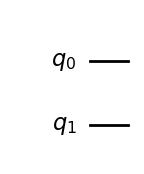

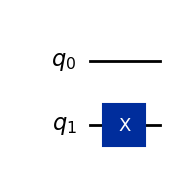

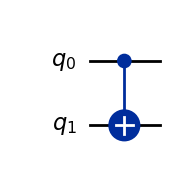

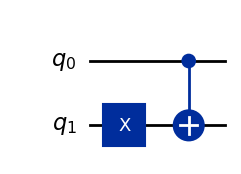

In [3]:
from qiskit import QuantumCircuit
def oracle(k):
    qc = QuantumCircuit(2)
    if k % 2 == 1:
        qc.x(1)
    if k >= 2:
        qc.cx(0, 1)
    return qc
# def oracle(k):
#     k = k % 4
#     if k == 0:
#         qc = QuantumCircuit(2)
#         return qc
#     if k == 1:
#         qc = QuantumCircuit(2)
#         qc.x(1)
#         return qc
#     if k == 2:
#         qc = QuantumCircuit(2)
#         qc.cx(0, 1)
#         return qc
#     if k == 3:
#         qc = QuantumCircuit(2)
#         qc.x(1)
#         qc.cx(0, 1)
#         return qc
display(oracle(0).draw("mpl"))
display(oracle(1).draw("mpl"))
display(oracle(2).draw("mpl"))
display(oracle(3).draw("mpl"))

## Quantum Parallelism
* Because we are implementing function computation as a unitary transform $U_f$, it can be applied to a general input state, say $a|x_1\rangle + b|x_2\rangle$
    $$U_f(a|x_1\rangle + b|x_2\rangle)|y\rangle = a|x_1\rangle|y\oplus f(x_1)\rangle + b|x_2\rangle|y\oplus f(x_2)\rangle$$
* In a single use of $U_f$, $f$ is computed at all input components.
* If the input state is linear combination of all possible input $x$, then a single use of $U_f$ can compute $f$ on all such inputs.
    $$U_f\sum_x a_x |x\rangle|y\rangle = \sum_x a_x |x\rangle|y\oplus f(x)\rangle$$
* **For any oracle $U_f$ of a Boolean function $f$, $|x\rangle|-\rangle$ are its eigenvectors with eigenvalue $(-1)^{f(x)}$**
                        $$U_f|x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle$$
    * Proof: $$\begin{align*}
    U_f|x\rangle|-\rangle &=U_f|x\rangle\left[\frac{|0\rangle - |1\rangle}{\sqrt{2}}\right]\\
    &= \left[\frac{|x\rangle|f(x)\rangle - |x\rangle|1\oplus f(x)\rangle}{\sqrt{2}}\right]\\
    &= |x\rangle\left[\frac{|f(x)\rangle - |1\oplus f(x)\rangle}{\sqrt{2}}\right]\\
    &= |x\rangle\left[(-1)^{f(x)}\frac{|0\rangle - |1\rangle}{\sqrt{2}}\right]\\
    &= (-1)^{f(x)}|x\rangle|-\rangle
    \end{align*}$$
* This is also known as **phase kick-back**.
* This observation is a key strategy in Deutsch algorithm.

# Deutsch's algorithm
$$\begin{align}
|\psi_0\rangle &= |0\rangle|1\rangle\\
\xrightarrow[H]{H}&\left[\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right]|-\rangle\\
= &\frac{1}{\sqrt{2}}\left[|0\rangle|-\rangle + |1\rangle|-\rangle\right]\\
= &\frac{1}{\sqrt{2}}\sum_x |x\rangle|-\rangle\\
\xrightarrow{U_f}&\frac{1}{\sqrt{2}}\sum_x (-1)^{f(x)}|x\rangle|-\rangle\\
=&\begin{cases}
\pm |+\rangle|-\rangle & \text{if }f(0) = f(1)\\
\pm |-\rangle|-\rangle & \text{if }f(0) \neq f(1)\\
\end{cases}\\
\xrightarrow{H}&\begin{cases}
\pm |0\rangle|-\rangle & \text{if }f(0) = f(1)\\
\pm |1\rangle|-\rangle & \text{if }f(0) \neq f(1)\\
\end{cases}\\
\xrightarrow{measure~1}&\begin{cases}
constant & \text{if outcome is } 0\\
balanced & \text{if outcome is } 1\\
\end{cases}\\
\end{align}$$

In [4]:
import numpy as np
# Choose a random function as oracle
def deutsch_oracle():
    k = np.random.randint(0, 4)
    uf = oracle(k)
    return uf

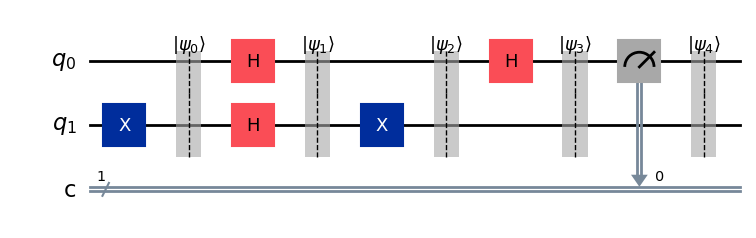

Circuit states:


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

0
Constant


<IPython.core.display.Latex object>

In [5]:
from qiskit import QuantumCircuit#, Aer, execute
from qiskit.quantum_info import Statevector
from qiskit.circuit import BoxOp

U_f = deutsch_oracle()

# deutsch()

def deutsch_state():
    qc = QuantumCircuit(2, 1)
    qc.x(1)                   # Set |1⟩ on target qubit
    ket_0 = Statevector(qc)
    lab_ket_0 = r"$|\psi_0\rangle$"
    qc.barrier(label=lab_ket_0)
    qc.h([0, 1])              # Hadamard on both qubits
    ket_1 = Statevector(qc)
    lab_ket_1 = r"$|\psi_1\rangle$"
    qc.barrier(label=lab_ket_1)
    # Attach oracle (choose 'balanced' or 'constant')
    Uf = U_f #BoxOp(ufgate, label="$U_f$")
    qc.compose(Uf, inplace=True)
    ket_2 = Statevector(qc)
    lab_ket_2 = r"$|\psi_2\rangle$"
    qc.barrier(label=lab_ket_2)
    qc.h(0)                   # Hadamard on first (input) qubit
    ket_3 = Statevector(qc)
    lab_ket_3 = r"$|\psi_3\rangle$"
    qc.barrier(label=lab_ket_3)
    qc.measure(0, 0)          # Measure input qubit
    outcomes, ket_4 = ket_3.measure([0]) # consider ideal measurement of statevector separately
    lab_ket_4 = r"$|\psi_4\rangle$"
    qc.barrier(label=lab_ket_4)
    display(qc.draw("mpl"))
    print('Circuit states:')
    showState(lab_ket_0, ket_0)
    showState(lab_ket_1, ket_1)
    showState(lab_ket_2, ket_2)
    showState(lab_ket_3, ket_3)
    print(outcomes)
    if outcomes == '0':
        print("Constant" )
    else:
        print("Balanced")
    showState(lab_ket_4, ket_4)

deutsch_state()
# Run and display result
# backend = Aer.get_backend('aer_simulator')
# job = execute(qc, backend, shots=1024)
# counts = job.result().get_counts(qc)
# print(counts)
# plot_histogram(counts)
